In [1]:
!pip install librosa --quiet
!pip install soundfile --quiet

In [2]:
import librosa
import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
from google.colab import files

# Настраиваем отображение графиков "прямо здесь"
%matplotlib inline

In [81]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

In [3]:

from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [4]:
file_path = '/content/drive/MyDrive/Colab Notebooks/DSP_2sem/lab2_gun/Стрельба на улице.wav'

In [5]:
signal, sr = librosa.load(file_path, sr=None, mono=False)

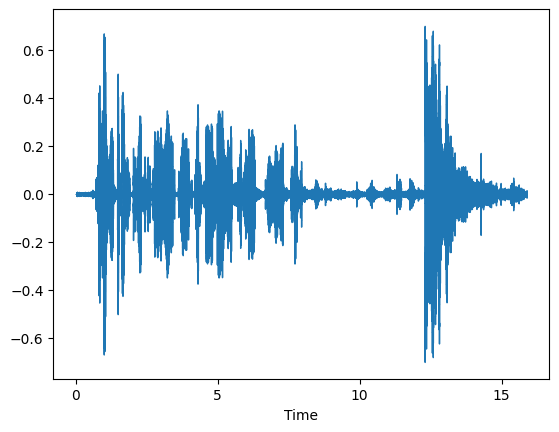

In [6]:
librosa.display.waveshow(signal, sr=sr)

In [9]:
signal.ndim

1

In [10]:
signal.shape

(254225,)

In [11]:
sig_length = signal.shape[0]

In [12]:
sig_length


254225

Выстрел раздается после 12 секунды

1) Разбиваем сигнал на окна по 1 секунде (1 сек * частоту дискретизации = длина в отсчетах) без пересечений

In [16]:
window_duration = 1.0
window_size = int(window_duration * sr)
hop_length = window_size


all_windows = []
for start in range(0, sig_length - window_size + 1, hop_length):
        window = signal[start:start + window_size]
        all_windows.append(window)

windows = np.array(all_windows)
kolvo_windows = len(windows)

In [17]:
print(f'Всего получилось {kolvo_windows} окон')

Всего получилось 15 окон


2. FFT для всех окон: возьмем модуль комплексных чисел - только первую половину таких модулей





In [34]:
spectrogramms = []

for i, window in enumerate(all_windows):
    fft_res = np.fft.fft(window)

    amplit_spectr = np.abs(fft_res)

    half_len = len(amplit_spectr) // 2
    amplit_spectr = amplit_spectr[:half_len]

    spectrogramms.append(amplit_spectr)




spectrogramms = np.array(spectrogramms)
spectrogramms.shape
print(f"\n Форма массива spectrogramms: {spectrogramms.shape}")
print(f"   • {spectrogramms.shape[0]} окон")
print(f"   • {spectrogramms.shape[1]} частотных бинов")


frequencies_full = np.fft.fftfreq(window_size, 1/sr)
frequencies = np.fft.fftfreq(window_size, 1/sr)[:window_size//2]
print(f'Спектр: {np.round(frequencies_full, 1)}')
print(f'Положительные частоты спектра: {np.round(frequencies, 1).astype(int)}')

print(f"\nДиапазон частот:")
print(f"• От: {frequencies[0]:.1f} Гц")
print(f"• До: {frequencies[-1]:.1f} Гц")
print(f"• Разрешение по частоте: {frequencies[1] - frequencies[0]:.2f} Гц")


 Форма массива spectrogramms: (15, 8000)
   • 15 окон
   • 8000 частотных бинов
Спектр: [ 0.  1.  2. ... -3. -2. -1.]
Положительные частоты спектра: [   0    1    2 ... 7997 7998 7999]

Диапазон частот:
• От: 0.0 Гц
• До: 7999.0 Гц
• Разрешение по частоте: 1.00 Гц


3) Просуммировать энергию в заданном диапазоне и сравнить с порогом

In [39]:
windows_to_analyze = [11, 12, 13, 14]  # индексы для окон 12-15
window_numbers = [12, 13, 14, 15]

In [40]:
for idx, win_num in zip(windows_to_analyze, window_numbers):
    spectrum = spectrogramms[idx]

    print(f"\n Окно {win_num} (индекс {idx}):")

    # Топ-5 частот с максимальной амплитудой
    top_indices = np.argsort(spectrum)[-5:][::-1]
    print("  Топ-5 частот с наибольшей амплитудой:")
    for pos, freq_idx in enumerate(top_indices, 1):
        freq = frequencies[freq_idx]
        amp = spectrum[freq_idx]
        print(f"    {pos}. {freq:.1f} Гц : амплитуда = {amp:.2f}")


 Окно 12 (индекс 11):
  Топ-5 частот с наибольшей амплитудой:
    1. 292.0 Гц : амплитуда = 16.00
    2. 362.0 Гц : амплитуда = 14.63
    3. 360.0 Гц : амплитуда = 14.28
    4. 352.0 Гц : амплитуда = 14.26
    5. 343.0 Гц : амплитуда = 12.61

 Окно 13 (индекс 12):
  Топ-5 частот с наибольшей амплитудой:
    1. 290.0 Гц : амплитуда = 118.58
    2. 501.0 Гц : амплитуда = 113.87
    3. 346.0 Гц : амплитуда = 107.77
    4. 490.0 Гц : амплитуда = 107.19
    5. 297.0 Гц : амплитуда = 105.58

 Окно 14 (индекс 13):
  Топ-5 частот с наибольшей амплитудой:
    1. 447.0 Гц : амплитуда = 56.75
    2. 434.0 Гц : амплитуда = 56.03
    3. 272.0 Гц : амплитуда = 54.14
    4. 360.0 Гц : амплитуда = 53.32
    5. 418.0 Гц : амплитуда = 52.84

 Окно 15 (индекс 14):
  Топ-5 частот с наибольшей амплитудой:
    1. 310.0 Гц : амплитуда = 19.72
    2. 354.0 Гц : амплитуда = 16.77
    3. 467.0 Гц : амплитуда = 15.56
    4. 266.0 Гц : амплитуда = 15.37
    5. 526.0 Гц : амплитуда = 15.36


In [45]:
top_frequencies = {}  # частоты
top_amplitudes = {}   # амплитуды


for idx, win_num in zip(windows_to_analyze, window_numbers):
    spectrum = spectrogramms[idx]

    # Находим индексы топ-5 частот
    top_indices = np.argsort(spectrum)[-5:][::-1]

    # Сохраняем частоты и амплитуды
    freqs = frequencies[top_indices]
    amps = spectrum[top_indices]

    top_frequencies[win_num] = freqs
    top_amplitudes[win_num] = amps

    print(f"\n Окно {win_num}:")
    for pos, (freq, amp) in enumerate(zip(freqs, amps), 1):
        print(f"    {pos}. {freq:.1f} Гц : амплитуда = {amp:.2f}")


 Окно 12:
    1. 292.0 Гц : амплитуда = 16.00
    2. 362.0 Гц : амплитуда = 14.63
    3. 360.0 Гц : амплитуда = 14.28
    4. 352.0 Гц : амплитуда = 14.26
    5. 343.0 Гц : амплитуда = 12.61

 Окно 13:
    1. 290.0 Гц : амплитуда = 118.58
    2. 501.0 Гц : амплитуда = 113.87
    3. 346.0 Гц : амплитуда = 107.77
    4. 490.0 Гц : амплитуда = 107.19
    5. 297.0 Гц : амплитуда = 105.58

 Окно 14:
    1. 447.0 Гц : амплитуда = 56.75
    2. 434.0 Гц : амплитуда = 56.03
    3. 272.0 Гц : амплитуда = 54.14
    4. 360.0 Гц : амплитуда = 53.32
    5. 418.0 Гц : амплитуда = 52.84

 Окно 15:
    1. 310.0 Гц : амплитуда = 19.72
    2. 354.0 Гц : амплитуда = 16.77
    3. 467.0 Гц : амплитуда = 15.56
    4. 266.0 Гц : амплитуда = 15.37
    5. 526.0 Гц : амплитуда = 15.36


In [42]:
all_top_freqs = np.concatenate(list(top_frequencies.values()))
all_top_amps = np.concatenate(list(top_amplitudes.values()))

print(f"\nВсего проанализировано частот: {len(all_top_freqs)}")
print(f"\nДиапазон топ-частот: {all_top_freqs.min():.1f} - {all_top_freqs.max():.1f} Гц")
print(f"Средняя частота в топ-5: {all_top_freqs.mean():.1f} Гц")
print(f"Медианная частота: {np.median(all_top_freqs):.1f} Гц")


Всего проанализировано частот: 20

Диапазон топ-частот: 266.0 - 526.0 Гц
Средняя частота в топ-5: 374.4 Гц
Медианная частота: 357.0 Гц


У выстрела - низкие частоты имеют максимальную амплитуду.

Возьмем порог для детектирования выстрела: 300 - 550 Гц

4) Подобрать порог на обучающей выборке


In [176]:
# ПРОСТОЙ ПОДБОР ДВУХ ПОРОГОВ - ТОЛЬКО ЗНАЧЕНИЯ

import numpy as np
from sklearn.metrics import f1_score

# Твои данные
freq_min, freq_max = 300, 550
shot_mask = (frequencies >= freq_min) & (frequencies <= freq_max)
energy_all = np.sum(spectrogramms[:, shot_mask], axis=1)

y_true = np.zeros(len(energy_all), dtype=int)
y_true[11] = 1  # окно 12
y_true[12] = 1  # окно 13
y_true[13] = 1  # окно 14
y_true[14] = 1  # окно 15

print("ЭНЕРГИЯ:", energy_all)
print("МЕТКИ:  ", y_true)
print()



ЭНЕРГИЯ: [ 4052.5867   5444.812    4462.817    2379.0974   4139.962    3718.9805
  3204.2744   3671.2495    813.4903    385.78235   422.36044   962.86755
 10987.645    5369.1973   1441.9463 ]
МЕТКИ:   [0 0 0 0 0 0 0 0 0 0 0 1 1 1 1]



In [167]:
low_porog = 900
low_porog_max = 1000
high_porog = 5000

print(f"\nПАРАМЕТРЫ КЛАССИФИКАТОРА:")
print(f"  • Нижний диапазон: {low_porog} - {low_porog_max}")
print(f"  • Верхний порог: > {high_porog}")


ПАРАМЕТРЫ КЛАССИФИКАТОРА:
  • Нижний диапазон: 900 - 1000
  • Верхний порог: > 5000


In [169]:
def detect_shot(energy):
    """
    Определяет, есть ли выстрел по энергии

Правило обнаружения выстрела:
   ЕСЛИ (энергия между {low_porog} и {low_porog_max})
   ИЛИ (энергия больше {high_porog})
   ТО это выстрел
    """
    # Если на вход пришло число
    if np.isscalar(energy):
        return 1 if (low_porog <= energy <= low_porog_max) or (energy > high_porog) else 0

    # Если на вход пришел массив
    predictions = []
    for e in energy:
        if (low_porog <= e <= low_porog_max) or (e > high_porog):
            predictions.append(1)
        else:
            predictions.append(0)
    return np.array(predictions)

In [170]:
freq_min, freq_max = 300, 550
shot_mask = (frequencies >= freq_min) & (frequencies <= freq_max)
energy_all = np.sum(spectrogramms[:, shot_mask], axis=1)

# 4. РАЗМЕТКА
y_true = np.zeros(len(energy_all), dtype=int)
y_true[11] = 1  # окно 12
y_true[12] = 1  # окно 13
y_true[13] = 1  # окно 14
y_true[14] = 1  # окно 15

In [171]:
y_pred = detect_shot(energy_all)


In [172]:
for i in range(len(energy_all)):
    верно = "✅" if y_true[i] == y_pred[i] else "❌"
    истина = "ВЫСТРЕЛ" if y_true[i] == 1 else "НЕТ"
    предсказание = "ВЫСТРЕЛ" if y_pred[i] == 1 else "НЕТ"
    print(f"{i+1:4d} | {energy_all[i]:8.2f} | {истина:7s} | {предсказание:11s} | {верно}")

   1 |  4052.59 | НЕТ     | НЕТ         | ✅
   2 |  5444.81 | НЕТ     | ВЫСТРЕЛ     | ❌
   3 |  4462.82 | НЕТ     | НЕТ         | ✅
   4 |  2379.10 | НЕТ     | НЕТ         | ✅
   5 |  4139.96 | НЕТ     | НЕТ         | ✅
   6 |  3718.98 | НЕТ     | НЕТ         | ✅
   7 |  3204.27 | НЕТ     | НЕТ         | ✅
   8 |  3671.25 | НЕТ     | НЕТ         | ✅
   9 |   813.49 | НЕТ     | НЕТ         | ✅
  10 |   385.78 | НЕТ     | НЕТ         | ✅
  11 |   422.36 | НЕТ     | НЕТ         | ✅
  12 |   962.87 | ВЫСТРЕЛ | ВЫСТРЕЛ     | ✅
  13 | 10987.64 | ВЫСТРЕЛ | ВЫСТРЕЛ     | ✅
  14 |  5369.20 | ВЫСТРЕЛ | ВЫСТРЕЛ     | ✅
  15 |  1441.95 | ВЫСТРЕЛ | НЕТ         | ❌


In [173]:
f1 = f1_score(y_true, y_pred, zero_division=0)
cm = confusion_matrix(y_true, y_pred)

print("\n" + "="*50)
print("МЕТРИКИ:")
print("="*50)
print(f"F1-score: {f1:.4f}")
print("\nМатрица ошибок:")
print(f"           Предсказано")
print(f"           НЕТ   ДА")
print(f"Истина НЕТ:  {cm[0,0]:3d}   {cm[0,1]:3d}")
print(f"       ДА:  {cm[1,0]:3d}   {cm[1,1]:3d}")



МЕТРИКИ:
F1-score: 0.7500

Матрица ошибок:
           Предсказано
           НЕТ   ДА
Истина НЕТ:   10     1
       ДА:    1     3
